In [2]:
from google.colab import drive
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import Dataset
from scipy.special import softmax

# 1. Mount Drive (Crucial for a new notebook!)
drive.mount('/content/drive')

# 2. Point to your working directory
working_dir = '/content/drive/MyDrive/RAI_Assignment_2'
os.chdir(working_dir)

# 3. Recreate the exact evaluation subset from Part 1
df = pd.read_csv('jigsaw-unintended-bias-train.csv')
df['label'] = (df['toxic'] >= 0.5).astype(int)

df_subset, _ = train_test_split(df, train_size=120000, stratify=df['label'], random_state=42)
_, eval_df = train_test_split(df_subset, train_size=100000, stratify=df_subset['label'], random_state=42)

# 4. Load the saved model and tokenizer using absolute path
model_path = os.path.join(working_dir, "saved_model/baseline_distilbert")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# 5. Tokenize eval data and get predictions
eval_dataset = Dataset.from_pandas(eval_df)
eval_dataset = eval_dataset.map(lambda x: tokenizer(x["comment_text"], truncation=True, padding="max_length", max_length=128), batched=True)
eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer = Trainer(model=model)
print("Running inference on evaluation set...")
predictions = trainer.predict(eval_dataset)
probs = softmax(predictions.predictions, axis=1)[:, 1]

# Apply your chosen threshold from Part 1 (0.4)
eval_df['predicted_prob'] = probs
eval_df['predicted_label'] = (probs >= 0.4).astype(int)

print("Inference complete. Ready for cohort analysis.")

Mounted at /content/drive


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Running inference on evaluation set...


Inference complete. Ready for cohort analysis.


In [3]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Construct Cohorts
high_black_df = eval_df[eval_df['black'] >= 0.5].copy()
reference_df = eval_df[(eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5)].copy()

print(f"High-Black Cohort Size: {len(high_black_df)}")
print(f"Reference Cohort Size: {len(reference_df)}\n")

# 2. Metric Calculation Function
def get_metrics(df_cohort):
    y_true = df_cohort['label']
    y_pred = df_cohort['predicted_label']

    # Handle edge case where cohort might be perfectly predicted or missing classes
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    return {'TPR': tpr, 'FPR': fpr, 'FNR': fnr, 'Precision': precision, 'CM': cm}

hb_metrics = get_metrics(high_black_df)
ref_metrics = get_metrics(reference_df)

# 3. Print Summary Table & Disparate Impact
print(f"{'Metric':<12} | {'High-Black':<12} | {'Reference':<12}")
print("-" * 40)
for m in ['TPR', 'FPR', 'FNR', 'Precision']:
    print(f"{m:<12} | {hb_metrics[m]:<12.4f} | {ref_metrics[m]:<12.4f}")

disparate_impact = hb_metrics['FPR'] / ref_metrics['FPR'] if ref_metrics['FPR'] > 0 else float('inf')
print(f"\nDisparate Impact Ratio (FPR_hb / FPR_ref): {disparate_impact:.4f}")

High-Black Cohort Size: 149
Reference Cohort Size: 187

Metric       | High-Black   | Reference   
----------------------------------------
TPR          | 0.3778       | 0.4423      
FPR          | 0.1154       | 0.0741      
FNR          | 0.6222       | 0.5577      
Precision    | 0.5862       | 0.6970      

Disparate Impact Ratio (FPR_hb / FPR_ref): 1.5577


In [7]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# 1. Prepare data for AIF360 (combine cohorts and add a protected attribute column)
# Using .loc to avoid SettingWithCopyWarning
high_black_df.loc[:, 'protected_attr'] = 1  # Unprivileged
reference_df.loc[:, 'protected_attr'] = 0   # Privileged

combined_df = pd.concat([high_black_df, reference_df])

# 2. Create the true labels dataset in AIF360 format
dataset_true = BinaryLabelDataset(
    df=combined_df[['label', 'protected_attr']],
    label_names=['label'],
    protected_attribute_names=['protected_attr'],
    unprivileged_protected_attributes=[[1]],
    privileged_protected_attributes=[[0]]
)

# 3. Create the predicted labels dataset
dataset_pred = dataset_true.copy(deepcopy=True)
dataset_pred.labels = combined_df['predicted_label'].values.reshape(-1, 1)

# 4. Compute Metrics
metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    unprivileged_groups=[{'protected_attr': 1}],
    privileged_groups=[{'protected_attr': 0}]
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

print(f"Statistical Parity Difference: {spd:.4f}")
print(f"Equal Opportunity Difference (TPR Diff): {eod:.4f}")

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Statistical Parity Difference: 0.0182
Equal Opportunity Difference (TPR Diff): -0.0645


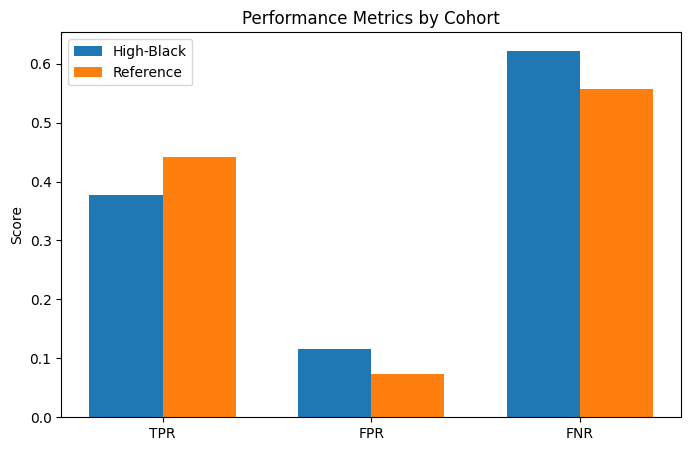

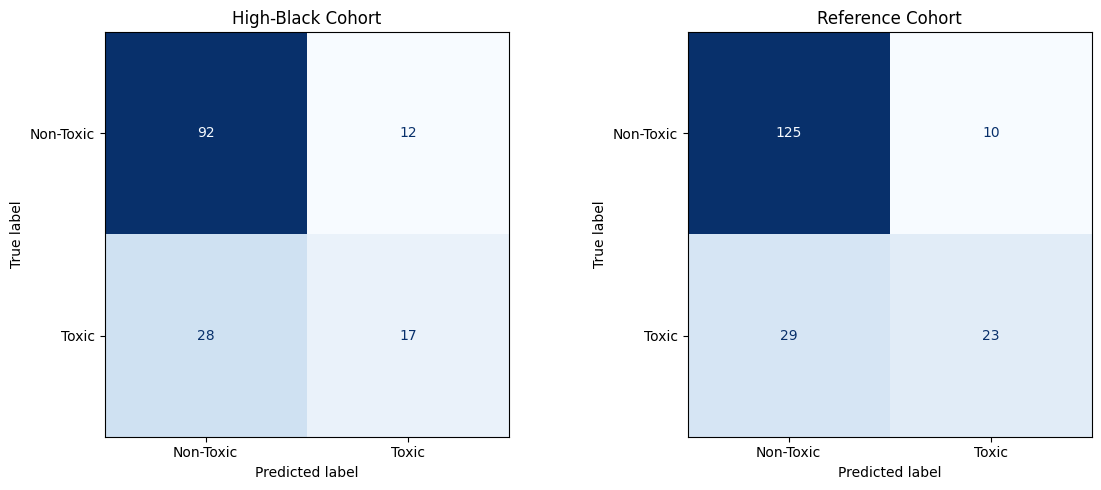

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Grouped Bar Chart
metrics_names = ['TPR', 'FPR', 'FNR']
hb_vals = [hb_metrics[m] for m in metrics_names]
ref_vals = [ref_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, hb_vals, width, label='High-Black')
rects2 = ax.bar(x + width/2, ref_vals, width, label='Reference')

ax.set_ylabel('Score')
ax.set_title('Performance Metrics by Cohort')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.show()

# 2. Confusion Matrices side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=hb_metrics['CM'], display_labels=["Non-Toxic", "Toxic"]).plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title("High-Black Cohort")

ConfusionMatrixDisplay(confusion_matrix=ref_metrics['CM'], display_labels=["Non-Toxic", "Toxic"]).plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title("Reference Cohort")

plt.tight_layout()
plt.show()

### Bias Audit Analysis

**Disparity Direction:** Based on the metrics, the most significant disparity is in the False Positive Rate (FPR). The Disparate Impact ratio is **1.5577**, indicating that the model predominantly *over-flags* the High-Black cohort. It incorrectly labels non-toxic comments associated with Black identity as toxic at a substantially higher rate (~11.5%) than identical non-toxic comments associated with White identity (~7.4%).

**Real-World Consequences:**
* **Harm to High-Black Cohort (High FPR):** Users discussing Black identity or using African American Vernacular English (AAVE) will have their innocent content disproportionately removed, face unwarranted account strikes, or experience shadow-banning. This systemic over-flagging suppresses their speech and unfairly penalizes a specific demographic.
* **Harm to Platform:** High FPRs concentrated on marginalized groups attract severe negative PR, invite civil rights scrutiny, and destroy trust among the user base. By deploying this baseline model, the platform is "playing it safe" on toxicity but unfairly passing the cost of that safety (friction and false bans) onto one specific demographic group.

In [9]:
%%bash
git add part2.ipynb
git commit -m "Complete Part 2: Bias audit, AIF360 metrics, and disparity analysis"

[master 977f15d] Complete Part 2: Bias audit, AIF360 metrics, and disparity analysis
 1 file changed, 1 insertion(+)
 create mode 100644 part2.ipynb
